#pip install numpy tensorflow matplotlib

# Step 1: Initialize the Q-table
**Initialize the Q-table to store the Q-values for each state-action pair. This table will be updated as the agent explores the environment and learns which actions yield the highest rewards.**

In [1]:
import numpy as np

# Define the grid size and actions
grid_size = 5
n_actions = 4  # Actions: up, down, left, right

# Initialize the Q-table with zeros
Q_table = np.zeros((grid_size * grid_size, n_actions))

# Step 2: Define the hyperparameters
Set the hyperparameters for Q-learning:

Learning rate (αα)

Discount factor (γγ)

Exploration rate (ϵϵ)

In [2]:
alpha = 0.1  # Learning rate
gamma = 0.9  # Discount factor for future rewards
epsilon = 0.1  # Exploration rate for epsilon-greedy policy

# Step 3: Define the reward structure
Create a reward matrix based on the environment's feedback:

+10 for reaching the goal

–10 for falling into the pit

–1 for other states

In [3]:
# Reward matrix for the grid environment
rewards = np.full((grid_size * grid_size,), -1)  # -1 for every state
rewards[24] = 10  # Goal state
rewards[12] = -10  # Pitfall state

#Step 4: Implement the epsilon-greedy action selection
The agent will use an epsilon-greedy policy to balance exploration and exploitation.

In [4]:
def epsilon_greedy_action(Q_table, state, epsilon):
    if np.random.uniform(0, 1) < epsilon:
        return np.random.randint(0, n_actions)  # Explore: random action
    else:
        return np.argmax(Q_table[state])  # Exploit: action with highest Q-value

# Step 5: Update the Q-values
Use the Bellman equation to update the Q-values based on the current state, the selected action, and the reward obtained.

In [12]:
rewards_q_learning = [] # List to store cumulative rewards per episode for Q-learning

for episode in range(1000):
    state = np.random.randint(0, grid_size * grid_size)  # Start in a random state
    done = False
    episode_total_reward = 0 # Initialize total reward for the current episode

    while not done:
        action = epsilon_greedy_action(Q_table, state, epsilon)
        next_state = np.random.randint(0, grid_size * grid_size)  # Simulated next state
        reward = rewards[next_state]

        episode_total_reward += reward # Accumulate reward for the current episode

        # Update Q-value using Bellman equation
        Q_table[state, action] = Q_table[state, action] + alpha * (reward + gamma * np.max(Q_table[next_state]) - Q_table[state, action])

        state = next_state
        if next_state == 24 or next_state == 12:
            done = True

    rewards_q_learning.append(episode_total_reward) # Store the total reward for the episode

# Implement policy gradients
The second part of the activity involves implementing policy gradients, a policy-based method in which the agent learns a policy (mapping from states to actions) by optimizing a neural network.

#Step-by-step guide:
#Step 1: Build the policy network
Define a neural network that takes the current state as input and then outputs a probability distribution over possible actions.

In [6]:
import tensorflow as tf

# Define the policy network
n_states = grid_size * grid_size  # Number of states in the grid
n_actions = 4  # Up, down, left, right

model = tf.keras.Sequential([
    tf.keras.layers.Dense(24, activation='relu', input_shape=(n_states,)),
    tf.keras.layers.Dense(n_actions, activation='softmax')  # Output action probabilities
])

# Optimizer for policy network updates
optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


#Step 2: Select an action
For each state, the agent selects an action based on the probabilities output by the policy network.

In [7]:
def get_action(state):
    state_input = tf.one_hot(state, n_states)  # One-hot encoding for state
    action_probs = model(state_input[np.newaxis, :])
    return np.random.choice(n_actions, p=action_probs.numpy()[0])

# Step 3: Simulate the environment
Simulate the environment as the agent selects actions and collects rewards.

In [13]:
rewards_policy_gradients = [] # List to store cumulative rewards per episode for Policy Gradients

# Policy gradient training loop
for episode in range(1000):
    state = np.random.randint(0, n_states)  # Start in a random state
    done = False
    current_episode_states = []
    current_episode_actions = []
    current_episode_step_rewards = []  # Rewards for steps within this specific episode

    while not done:
        action = get_action(state)  # Use the policy network to select an action
        next_state = np.random.randint(0, n_states)  # Simulated next state
        reward = rewards[next_state]

        # Store the state-action-reward trajectory for the current episode
        current_episode_states.append(state)
        current_episode_actions.append(action)
        current_episode_step_rewards.append(reward)

        state = next_state
        if next_state in {24, 12}:  # Check for terminal states (goal or pit)
            done = True

    # After the episode ends, update the policy and store the episode's cumulative reward
    if current_episode_states: # Ensure the episode had at least one step
        update_policy(current_episode_states, current_episode_actions, current_episode_step_rewards)
        # Calculate and store the discounted cumulative reward for this episode
        # The first element of compute_cumulative_rewards output is the total discounted return for the episode
        cumulative_reward_for_episode = compute_cumulative_rewards(current_episode_step_rewards)[0]
        rewards_policy_gradients.append(cumulative_reward_for_episode)

# Step 4: Compute cumulative rewards
To reinforce actions that lead to long-term success, calculate the cumulative rewards for each action taken during an episode.

In [9]:
def compute_cumulative_rewards(rewards, gamma=0.99):
    cumulative_rewards = np.zeros_like(rewards)
    running_add = 0
    for t in reversed(range(len(rewards))):
        running_add = running_add * gamma + rewards[t]
        cumulative_rewards[t] = running_add
    return cumulative_rewards

#Step 5: Update the policy
Update the policy network using the REINFORCE algorithm based on the actions and cumulative rewards.

In [10]:
def update_policy(states, actions, rewards):
    cumulative_rewards = compute_cumulative_rewards(rewards)

    with tf.GradientTape() as tape:
        state_inputs = tf.one_hot(states, n_states)  # Convert states to one-hot encoding
        action_probs = model(state_inputs)
        action_masks = tf.one_hot(actions, n_actions)  # Mask for selected actions
        log_probs = tf.reduce_sum(action_masks * tf.math.log(action_probs), axis=1)

        # Policy loss is the negative log-probability of the action times the cumulative reward
        loss = -tf.reduce_mean(log_probs * cumulative_rewards)

    # Apply gradients to update the policy network
    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))

# Comparison and analysis
After implementing both Q-learning and policy gradients, it’s time to compare their performance. Here’s what to consider:

Convergence speed: how quickly does each algorithm learn an optimal policy?

Reward maximization: which algorithm achieves higher cumulative rewards?

Exploration vs. exploitation: how do Q-learning and policy gradients handle exploration of the environment?

Suitability: which algorithm is better suited for this environment, and why?

Use Matplotlib to visualize the cumulative rewards over episodes and compare how each algorithm performs.

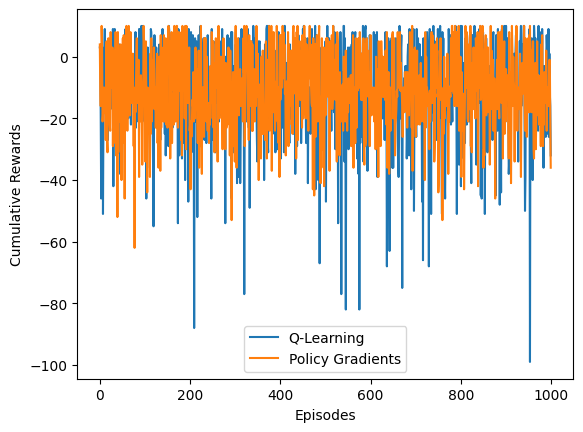

In [14]:
import matplotlib.pyplot as plt

# Example code to visualize rewards over episodes
plt.plot(rewards_q_learning, label='Q-Learning')
plt.plot(rewards_policy_gradients, label='Policy Gradients')
plt.xlabel('Episodes')
plt.ylabel('Cumulative Rewards')
plt.legend()
plt.show()